# Notebook 3 — Keras Utility-Based Pipeline (`image_dataset_from_directory`)

This notebook demonstrates Keras's built-in loading utility and the `tf.data` augmentation pipeline:
- `image_dataset_from_directory` — directory-based loading (demo/experimentation only)
- `tf.keras.layers` augmentation — `RandomFlip`, `RandomRotation`, `RandomZoom`
- `tf.data` performance — `.map()`, `.cache()`, `.prefetch()`

> ⚠️ **Important:** `image_dataset_from_directory` with `validation_split` is used here for **demonstration only**.
> All actual training in Stages 2 & 3 must use the CSV splits from Notebook 2.

In [1]:
print("python")

python


In [2]:
#%load_ext autotime
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

PROJECT_ROOT = '..'
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')

## Keras' built-in utility

In [4]:
batch_size = 8

In [5]:
# Create a training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR,
    labels='inferred',          # Labels are generated from directory structure
    label_mode='int',           # Labels are encoded as integers (0, 1, ...)
    validation_split=0.2,       # 20% of images for validation
    subset='training',          
    seed=1337,                  # Shuffle seed
    batch_size=batch_size
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    PROCESSED_DIR,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    batch_size=batch_size
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


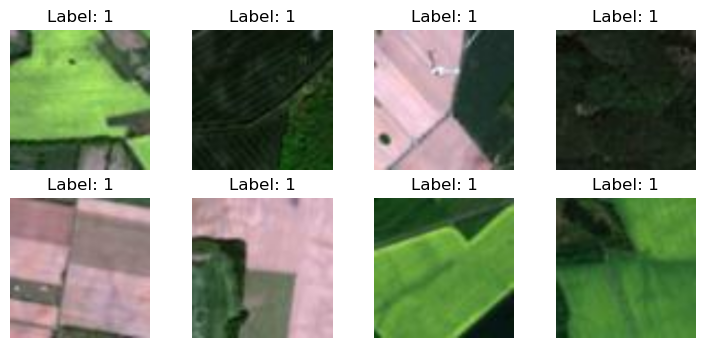

In [7]:
plt.figure(figsize=(9, 4))
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(batch_size):
        ax = plt.subplot(2, 4, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Label: {int(labels[i])}")
        plt.axis("off")

## Data Augmentation

In [8]:
# Normalization (ALL data)
normalization = tf.keras.layers.Rescaling(1.0 / 255)

# Augmentation (TRAIN ONLY)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.1),
])

# # Train
# train_ds = train_ds.map(lambda x, y: (normalization(x), y))
# train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# # Validation
# val_ds = val_ds.map(lambda x, y: (normalization(x), y))

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

# Train: normalize + augment together
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization(x), training=True), y),
    num_parallel_calls=AUTOTUNE
)

# Validation: only normalize
val_ds = val_ds.map(
    lambda x, y: (normalization(x), y),
    num_parallel_calls=AUTOTUNE
)

# Performance
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)